# EEG seizure detection (chb04): lean version

**Task:** look at a 10-second piece of EEG and answer *seizure* or *no seizure*.

**What this notebook does**
1. Gets a **few recordings** (the ones with seizures, plus a couple without).
2. Cleans them and cuts them into 10-second windows.
3. Runs **k-fold cross-validation**: each seizure recording takes one turn as the test, and the model trains on the others. We split by *recording* (not random windows) because neighbouring windows are almost identical, and a random split would let the model "see the answers".
4. Prints the usual metrics: confusion matrix, precision, recall, F1, ROC and PR curves, plus how many seizures were actually found.

Run top to bottom on a **GPU** runtime (Runtime > Change runtime type > T4).

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%pip install -q mne

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 59.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [2]:
import os, re, glob, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_recall_fscore_support, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report, roc_curve, precision_recall_curve)

# ---------------- SETTINGS (edit here) ----------------
ROOT = "/content/drive/MyDrive/EEGproj"
PATIENTS = ["chb01", "chb03", "chb04", "chb15","chb10"]
N_SEIZURE_FILES = 3    # recordings that contain seizures (None = use all of them)
N_NORMAL_FILES  = 0     # seizure-free recordings to add
EPOCHS = 20              # start small to test quickly; raise to 40+ for a real run
THRESHOLD = 0.5          # alarm / "seizure" when probability >= this
SEED = 42

FS_NEW = 128             # we work at 128 Hz (keeping 0.5-40 Hz)
CHANNELS = ["FP1-F7", "F7-T7", "T7-P7", "P7-O1", "FP1-F3", "F3-C3", "C3-P3", "P3-O1",
            "FP2-F4", "F4-C4", "C4-P4", "P4-O2", "FP2-F8", "F8-T8", "T8-P8-0", "P8-O2",
            "FZ-CZ", "CZ-PZ"]
WIN_S, MIN_OVERLAP_S = 5, 2.5      # 5 s windows; "seizure window" = at least 2.5 s inside a seizure
EVAL_STEP_S, SMOOTH = 1, 3        # test windows every 1 s, scores smoothed over 3 windows
BATCH, LR = 64, 1e-3
NORMAL_PER_SEIZURE = 4           # each round: all seizure windows + 3x as many random normal windows
# -------------------------------------------------------

SUMMARY_NAME = "summary.txt"
BASE_URL = "https://physionet.org/files/chbmit/1.0.0"
OUT_FOLDER = os.path.join(ROOT, "processed")
os.makedirs(OUT_FOLDER, exist_ok=True)
WIN = WIN_S * FS_NEW
N_CH = len(CHANNELS)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 2. Get and clean the data
`chb04-summary.txt` lists when every seizure starts and ends. We pick the recordings with seizures, add a couple without, download whatever is missing, then clean each one (band-pass 0.5-40 Hz, downsample to 128 Hz, normalize each channel).

In [3]:
def find_file_path(filename, root_dir=ROOT):
    hits = glob.glob(os.path.join(root_dir, "**", filename), recursive=True)
    return hits[0] if hits else None

def fetch(filename):
    path = find_file_path(filename)
    if path:
        return path
    patient = filename[:5]                                   # "chb04"
    dest = os.path.join(ROOT, patient); os.makedirs(dest, exist_ok=True)
    os.system(f"wget -nc -q -P '{dest}' {BASE_URL}/{patient}/{filename}")
    path = find_file_path(filename)
    if not path:
        raise FileNotFoundError(filename)
    return path

def parse_summary(path):
    """Returns {edf_name: [(start_s, end_s), ...]}"""
    text = open(path, errors="ignore").read()
    out = {}
    for block in re.split(r"File Name:\s*", text)[1:]:
        name = block.split()[0]
        starts = re.findall(r"Seizure\s*\d*\s*Start Time:\s*(\d+)", block)
        ends   = re.findall(r"Seizure\s*\d*\s*End Time:\s*(\d+)", block)
        out[name] = [(int(a), int(b)) for a, b in zip(starts, ends)]
    return out

SUMMARY = {}
for p in PATIENTS:
    SUMMARY.update(parse_summary(fetch(f"{p}-summary.txt")))

FILES = []
for p in PATIENTS:
    mine = [f for f in SUMMARY if f.startswith(p + "_")]
    FILES += [f for f in mine if SUMMARY[f]][:N_SEIZURE_FILES]
    FILES += [f for f in mine if not SUMMARY[f]][:N_NORMAL_FILES]
for f in FILES:
    fetch(f)
print(len(FILES), "recordings")

12 recordings


In [4]:
import mne
mne.set_log_level("ERROR")

def preprocess_file(fname):
    cache = os.path.join(OUT_FOLDER, fname.replace(".edf", f"_fs{FS_NEW}_c{N_CH}.npz"))
    seizures = np.array(SUMMARY[fname], dtype=int).reshape(-1, 2)
    if os.path.exists(cache):
        d = np.load(cache)
        return dict(signal=d["signal"], seizures=d["seizures"])

    raw = mne.io.read_raw_edf(fetch(fname), preload=True, verbose=False)
    if "T8-P8" in raw.ch_names:
        raw.rename_channels({"T8-P8": "T8-P8-0"})
    missing = [c for c in CHANNELS if c not in raw.ch_names]
    if missing:
        raise ValueError(f"{fname}: missing channels {missing}")
    raw.pick(CHANNELS)
    raw.filter(0.5, 40.0, verbose=False)
    raw.resample(FS_NEW, verbose=False)
    sig = raw.get_data().astype(np.float32) * 1e6

    med = np.median(sig, axis=1, keepdims=True)
    q75, q25 = np.percentile(sig, [75, 25], axis=1)
    sig = (sig - med) / ((q75 - q25)[:, None] + 1e-6)
    sig = np.clip(sig, -20, 20)

    np.savez_compressed(cache, signal=sig, seizures=seizures)
    return dict(signal=sig, seizures=seizures)

DATA = {}
for f in FILES:
    try:
        DATA[f] = preprocess_file(f)
    except Exception as e:
        print(f"SKIPPED {f}: {e}")        # some patients use different electrode names

PATIENTS_OK = [p for p in PATIENTS
               if any(f.startswith(p + "_") and len(d["seizures"]) for f, d in DATA.items())]
DATA = {f: d for f, d in DATA.items() if f[:5] in PATIENTS_OK}
assert len(PATIENTS_OK) >= 2, "Need at least 2 patients with usable seizure recordings"
print("Patients used:", PATIENTS_OK)

/tmp/ipykernel_1405/171718434.py:11: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(fetch(fname), preload=True, verbose=False)
/tmp/ipykernel_1405/171718434.py:11: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(fetch(fname), preload=True, verbose=False)
/tmp/ipykernel_1405/171718434.py:11: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(fetch(fname), preload=True, verbose=False)


Patients used: ['chb01', 'chb03', 'chb04', 'chb15']


## 3. The k folds
One fold per seizure recording. In each fold the test set is that recording (plus one seizure-free recording, so we can count false alarms) and everything else is used for training.

In [5]:
FOLDS = []
for p in PATIENTS_OK:
    test = [f for f in DATA if f.startswith(p + "_")]
    FOLDS.append(dict(name=p, test=test, train=[f for f in DATA if f not in test]))

for k, fd in enumerate(FOLDS):
    n_tr = sum(len(DATA[f]["seizures"]) for f in fd["train"])
    n_te = sum(len(DATA[f]["seizures"]) for f in fd["test"])
    print(f"fold {k + 1}: test patient {fd['name']} ({n_te} seizures) | train on {len(fd['train'])} recordings ({n_tr} seizures)")

fold 1: test patient chb01 (2 seizures) | train on 9 recordings (6 seizures)
fold 2: test patient chb03 (2 seizures) | train on 9 recordings (6 seizures)
fold 3: test patient chb04 (2 seizures) | train on 9 recordings (6 seizures)
fold 4: test patient chb15 (2 seizures) | train on 9 recordings (6 seizures)


## 4. The model
Windows are cut from the cleaned signal, and **EEGNet** (a small convolutional network made for EEG) learns to label them. Each training round uses all seizure windows plus a fresh random sample of normal windows, because normal windows vastly outnumber seizure ones.

In [6]:
def overlaps(starts, seizures):
    """seconds of each window [t, t+10] that lie inside a seizure"""
    ov = np.zeros(len(starts))
    for a, b in seizures:
        ov += np.clip(np.minimum(starts + WIN_S, b) - np.maximum(starts, a), 0, None)
    return ov

def window_items(files):
    """All usable training windows on a 1-second grid: seizure ones and clearly-normal ones."""
    pos, neg = [], []
    for f in files:
        dur = DATA[f]["signal"].shape[1] / FS_NEW
        t = np.arange(0, int(dur) - WIN_S + 1)
        ov = overlaps(t, DATA[f]["seizures"])
        pos += [(f, int(x)) for x in t[ov >= MIN_OVERLAP_S]]
        neg += [(f, int(x)) for x in t[ov == 0]]          # ambiguous half-and-half windows are skipped
    return pos, neg

def make_windows(items, augment, rng=None):
    xs = []
    for f, t in items:
        sig = DATA[f]["signal"]
        s = int(t * FS_NEW)
        if augment:
            # 1. Décalage temporel (shift)
            s += int(rng.integers(-FS_NEW // 2, FS_NEW // 2 + 1))

        s = int(np.clip(s, 0, sig.shape[1] - WIN))
        x = sig[:, s:s + WIN].copy()

        if augment:
            # 2. Changement d'amplitude
            x *= rng.uniform(0.80, 1.20)
            # 3. Bruit Gaussien léger
            x += rng.normal(0, 0.05, x.shape).astype(np.float32)

            # 4. Masquage temporel (Time Masking) : met à zéro une petite portion du signal
            if rng.random() < 0.5:
                mask_len = rng.integers(5, int(WIN * 0.15)) # Masque jusqu'à 15% de la fenêtre
                start_mask = rng.integers(0, WIN - mask_len)
                x[:, start_mask:start_mask + mask_len] = 0

            # 5. Désactivation d'un canal aléatoire
            if rng.random() < 0.3:
                x[int(rng.integers(0, N_CH))] = 0

        xs.append(x)
    return torch.tensor(np.stack(xs)[:, None, :, :], dtype=torch.float32)

In [7]:
class EEGNet(nn.Module):
    def __init__(self, n_ch, n_times, F1=8, D=2, F2=16, kern=63, drop=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern), padding="same", bias=False),        # learns frequency filters
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, (n_ch, 1), groups=F1, bias=False),        # learns spatial patterns (electrodes)
            nn.BatchNorm2d(F1 * D), nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(drop))
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 15), padding="same", groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, 1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1, 8)), nn.Dropout(drop))
        with torch.no_grad():
            n_feat = self.block2(self.block1(torch.zeros(1, 1, n_ch, n_times))).numel()
        self.head = nn.Linear(n_feat, 2)

    def forward(self, x):
        return self.head(self.block2(self.block1(x)).flatten(1))

def secure_undersample(pos, neg, rng):
    """
    Sous-échantillonne aléatoirement la classe majoritaire (sans crise).
    Effectué à chaque époque uniquement sur les données de train pour éviter toute fuite.
    """
    n_neg = min(len(neg), NORMAL_PER_SEIZURE * len(pos))
    selected_neg = [neg[i] for i in rng.choice(len(neg), n_neg, replace=False)]
    items = pos + selected_neg
    labels = [1] * len(pos) + [0] * n_neg
    return items, labels

def train_eegnet(train_files, shuffle=False, seed=SEED, verbose=True):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)

    # Extraction des fenêtres strictement sur le set d'entraînement
    pos, neg = window_items(train_files)
    if len(pos) == 0:
        raise RuntimeError("No seizure windows in the training files")

    model = EEGNet(N_CH, WIN).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    lossf = nn.CrossEntropyLoss()

    for ep in range(1, EPOCHS + 1):
        # Application de l'undersampling à chaque nouvelle époque
        items, labels = secure_undersample(pos, neg, rng)
        labels = np.array(labels)

        if shuffle:
            rng.shuffle(labels)
        order = rng.permutation(len(items))

        model.train()
        total = 0.0
        for i in range(0, len(order), BATCH):
            idx = order[i:i + BATCH]
            if len(idx) < 2:
                continue
            xb = make_windows([items[j] for j in idx], True, rng).to(device)
            yb = torch.tensor(labels[idx]).to(device)
            opt.zero_grad()
            loss = lossf(model(xb), yb)
            loss.backward()
            opt.step()
            total += loss.item() * len(idx)
        sched.step()

        if verbose and (ep == 1 or ep % 10 == 0 or ep == EPOCHS):
            print(f"    round {ep:3d}/{EPOCHS} | training loss {total / len(items):.4f} "
                  f"({len(pos)} seizure windows, {len(items) - len(pos)} normal)")
    return model

def eegnet_predict(model, items):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(items), 128):
            xb = make_windows(items[i:i + 128], False).to(device)
            out.append(torch.softmax(model(xb), dim=1)[:, 1].cpu().numpy())
    return np.concatenate(out)

## 5. Run the cross-validation
For each fold: train a fresh model, then slide a window over the **whole** test recordings (including every quiet hour) and store the probability of seizure for each window.

In [8]:
def run_cv():
    out = []
    for k, fd in enumerate(FOLDS):
        print(f"fold {k + 1}/{len(FOLDS)}: test on {fd['test']}")
        model = train_eegnet(fd["train"], seed=SEED + k)
        for f in fd["test"]:
            dur = DATA[f]["signal"].shape[1] / FS_NEW
            starts = np.arange(0, int(dur) - WIN_S + 1, EVAL_STEP_S)
            raw = eegnet_predict(model, [(f, int(s)) for s in starts])
            p = np.convolve(raw, np.ones(SMOOTH) / SMOOTH, mode="same")
            y = (overlaps(starts, DATA[f]["seizures"]) >= MIN_OVERLAP_S).astype(int)
            out.append(dict(fold=fd["name"], file=f, starts=starts, p=p, y=y,
                            seizures=DATA[f]["seizures"], hours=dur / 3600))
        del model
        if device == "cuda":
            torch.cuda.empty_cache()
    return out

t0 = time.time()
RESULTS = run_cv()
print(f"\nDone in {(time.time() - t0) / 60:.1f} min")

fold 1/4: test on ['chb01_03.edf', 'chb01_04.edf', 'chb01_01.edf']
    round   1/20 | training loss 0.5590 (439 seizure windows, 1317 normal)
    round  10/20 | training loss 0.0916 (439 seizure windows, 1317 normal)
    round  20/20 | training loss 0.0728 (439 seizure windows, 1317 normal)
fold 2/4: test on ['chb03_01.edf', 'chb03_02.edf', 'chb03_05.edf']
    round   1/20 | training loss 0.6086 (389 seizure windows, 1167 normal)
    round  10/20 | training loss 0.0930 (389 seizure windows, 1167 normal)
    round  20/20 | training loss 0.0993 (389 seizure windows, 1167 normal)
fold 3/4: test on ['chb04_05.edf', 'chb04_08.edf', 'chb04_01.edf']
    round   1/20 | training loss 0.5619 (346 seizure windows, 1038 normal)
    round  10/20 | training loss 0.0773 (346 seizure windows, 1038 normal)
    round  20/20 | training loss 0.0998 (346 seizure windows, 1038 normal)
fold 4/4: test on ['chb15_06.edf', 'chb15_10.edf', 'chb15_01.edf']
    round   1/20 | training loss 0.5777 (350 seizure wind

## 6. Metrics
Seizure windows are rare (around 1% of all windows), so **plain accuracy is useless**: always answering "no seizure" would score ~99%. Look at these instead:

| Metric | Plain meaning |
|---|---|
| **Recall** (sensitivity) | Of the real seizure windows, how many did we catch? |
| **Precision** | Of the windows we flagged, how many were real seizures? |
| **F1** | One number balancing precision and recall |
| **ROC-AUC** | How well seizure windows rank above normal ones (0.5 = coin flip). Can look flattering when seizures are rare |
| **PR-AUC** | Same idea, but honest about rare events. Compare it with the "random" value (the share of seizure windows) |
| **Seizures found / false alarms per hour** | The event-level view doctors care about |

Everything below uses a fixed threshold (`THRESHOLD`), so the numbers are not tuned on the test data.

In [9]:
FOLD_NAMES = list(dict.fromkeys(r["fold"] for r in RESULTS))

def fold_arrays(name):
    rs = [r for r in RESULTS if r["fold"] == name]
    return np.concatenate([r["y"] for r in rs]), np.concatenate([r["p"] for r in rs])

def find_events(score, starts, thr):
    on, ev, i = score >= thr, [], 0
    while i < len(on):
        if on[i]:
            j = i
            while j + 1 < len(on) and on[j + 1]:
                j += 1
            ev.append((int(starts[i]), int(starts[j]) + WIN_S)); i = j + 1
        else:
            i += 1
    return ev

def event_counts(rs, thr):
    """seizures found, total seizures, false alarms, hours tested"""
    found = total = false_alarms = 0; hours = 0.0
    for r in rs:
        ev = find_events(r["p"], r["starts"], thr)
        for a, b in r["seizures"]:
            total += 1; found += any(e0 < b and e1 > a for e0, e1 in ev)
        false_alarms += sum(not any(e0 < b and e1 > a for a, b in r["seizures"]) for e0, e1 in ev)
        hours += r["hours"]
    return found, total, false_alarms, hours

rows = []
for name in FOLD_NAMES:
    y, p = fold_arrays(name)
    pr, rc, f1, _ = precision_recall_fscore_support(y, (p >= THRESHOLD).astype(int), average="binary", zero_division=0)
    found, total, fa, h = event_counts([r for r in RESULTS if r["fold"] == name], THRESHOLD)
    rows.append({"test patient": name, "seizure windows": int(y.sum()), "precision": pr, "recall": rc, "F1": f1,
                 "ROC-AUC": roc_auc_score(y, p), "PR-AUC": average_precision_score(y, p), "random PR-AUC": y.mean(),
                 "seizures found": f"{found}/{total}", "false alarms/h": fa / h})
table = pd.DataFrame(rows).set_index("test patient")
print(f"=== Per fold (threshold {THRESHOLD}) ===")
display(table.round(3))

num = table.drop(columns=["seizures found"])
print("=== Mean and spread across folds ===")
display(num.agg(["mean", "std"]).round(3))

=== Per fold (threshold 0.5) ===


,seizure windows,precision,recall,F1,ROC-AUC,PR-AUC,random PR-AUC,seizures found,false alarms/h
test patient,,,,,,,,,
chb01,13,0.667,0.923,0.774,0.999,0.928,0.006,2/2,0.333
chb03,23,0.500,0.783,0.610,0.981,0.759,0.011,2/2,2.667
chb04,32,0.111,0.688,0.190,0.767,0.429,0.004,1/2,4.414
chb15,31,0.000,0.000,0.000,0.898,0.122,0.014,0/2,0.333


=== Mean and spread across folds ===


,seizure windows,precision,recall,F1,ROC-AUC,PR-AUC,random PR-AUC,false alarms/h
mean,24.750,0.319,0.598,0.394,0.911,0.559,0.009,1.937
std,8.808,0.316,0.410,0.360,0.106,0.358,0.005,1.984


=== All folds pooled: classification report ===
                precision    recall  f1-score   support

no seizure (0)       1.00      0.99      0.99     14035
   seizure (1)       0.20      0.53      0.29        99

      accuracy                           0.98     14134
     macro avg       0.60      0.76      0.64     14134
  weighted avg       0.99      0.98      0.99     14134



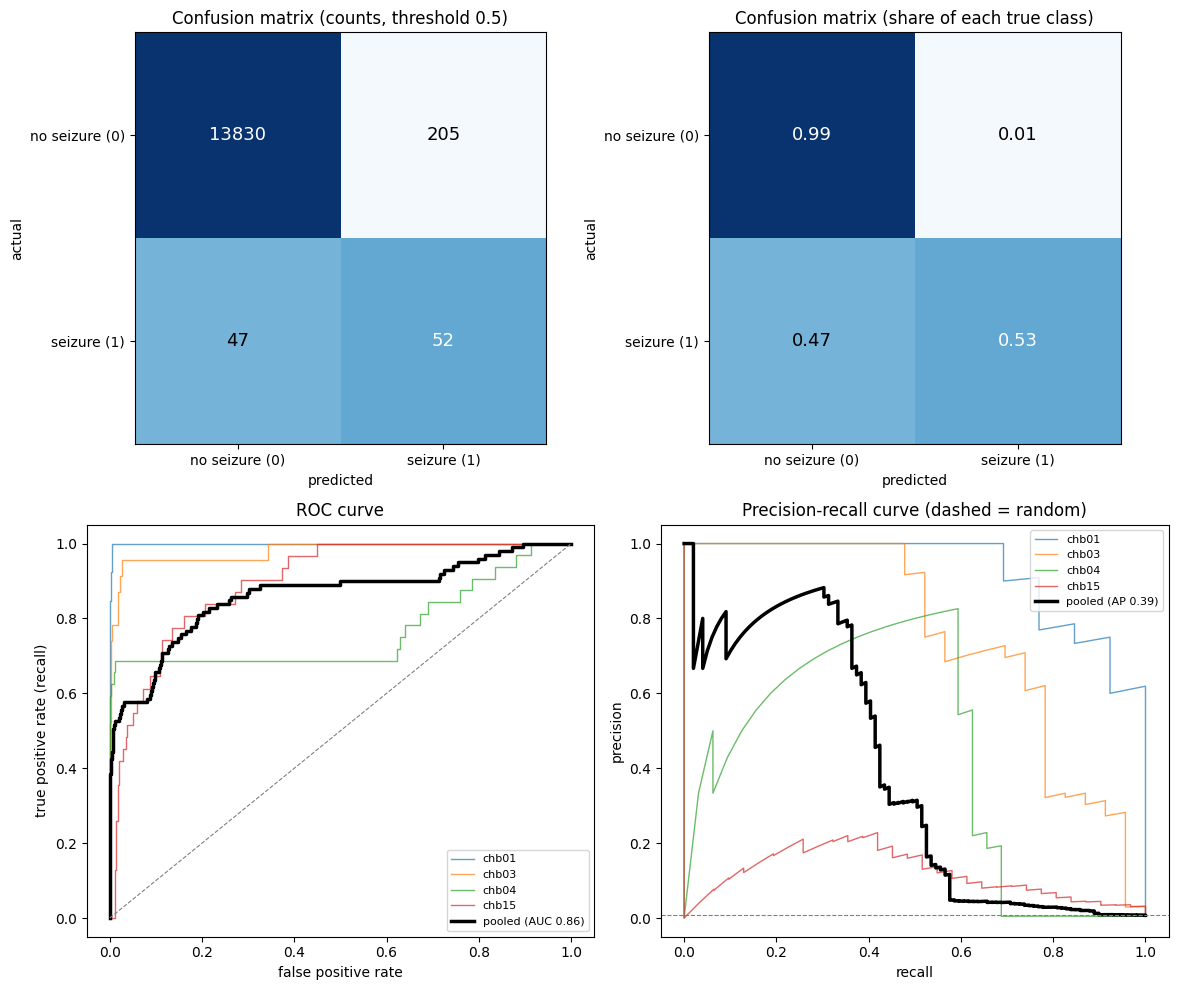

In [10]:
y_all = np.concatenate([fold_arrays(n)[0] for n in FOLD_NAMES])
p_all = np.concatenate([fold_arrays(n)[1] for n in FOLD_NAMES])
pred_all = (p_all >= THRESHOLD).astype(int)
labels = ["no seizure (0)", "seizure (1)"]

print("=== All folds pooled: classification report ===")
print(classification_report(y_all, pred_all, target_names=labels, zero_division=0))

def draw_cm(ax, m, shade, title, fmt):
    ax.imshow(shade, cmap="Blues", vmin=0, vmax=1)          # colour = share of each true class, so the rare class is visible
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(m[i, j], fmt), ha="center", va="center",
                    color="white" if shade[i, j] > 0.5 else "black", fontsize=13)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels); ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title(title)

cm = confusion_matrix(y_all, pred_all)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
draw_cm(axes[0, 0], cm, cm_norm, f"Confusion matrix (counts, threshold {THRESHOLD})", "d")
draw_cm(axes[0, 1], cm_norm, cm_norm, "Confusion matrix (share of each true class)", ".2f")

ax = axes[1, 0]
for name in FOLD_NAMES:
    y, p = fold_arrays(name); fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, lw=1, alpha=0.7, label=name)
fpr, tpr, _ = roc_curve(y_all, p_all)
ax.plot(fpr, tpr, lw=2.5, color="black", label=f"pooled (AUC {roc_auc_score(y_all, p_all):.2f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=0.8)
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate (recall)"); ax.set_title("ROC curve"); ax.legend(fontsize=8)

ax = axes[1, 1]
for name in FOLD_NAMES:
    y, p = fold_arrays(name); pr_, rc_, _ = precision_recall_curve(y, p)
    ax.plot(rc_, pr_, lw=1, alpha=0.7, label=name)
pr_, rc_, _ = precision_recall_curve(y_all, p_all)
ax.plot(rc_, pr_, lw=2.5, color="black", label=f"pooled (AP {average_precision_score(y_all, p_all):.2f})")
ax.axhline(y_all.mean(), ls="--", color="gray", lw=0.8)
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_title("Precision-recall curve (dashed = random)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Seizure-level view and thresholds
Window metrics treat every 10 s piece equally. A doctor cares about something simpler: **was each seizure caught, and how often did the system cry wolf?** The table also shows what happens as the alarm threshold moves (a trade-off: lower finds more seizures but raises more false alarms).

,seizures found,false alarms/h,window precision,window recall
threshold,,,,
0.3,5/8,4.78,0.122,0.566
0.5,5/8,2.90,0.202,0.525
0.7,5/8,1.98,0.341,0.444
0.9,5/8,0.87,0.533,0.404


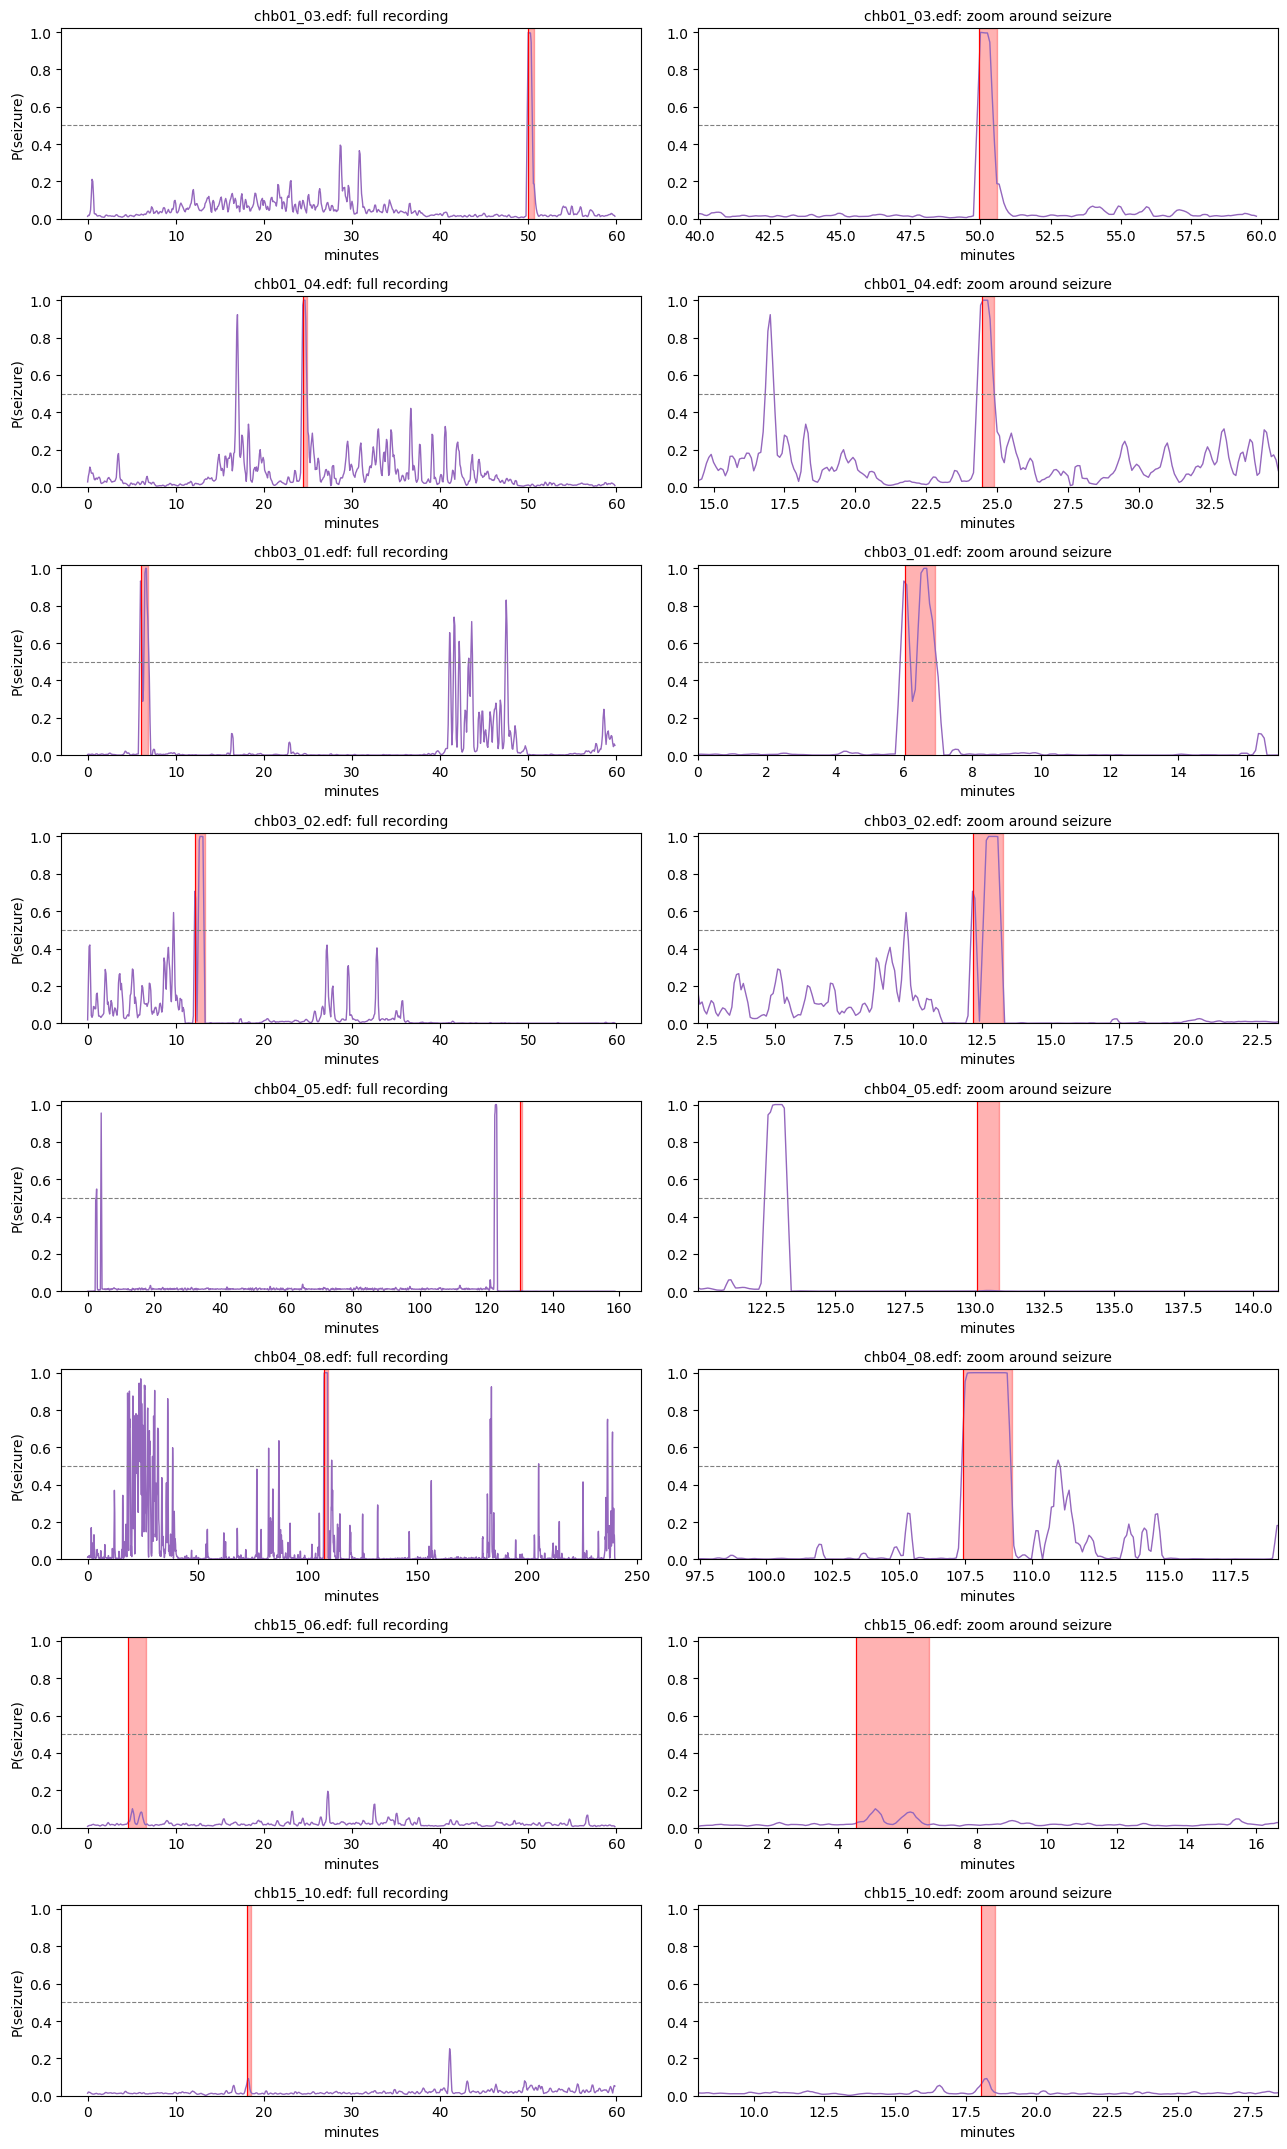

In [11]:
rows = []
for thr in (0.3, 0.5, 0.7, 0.9):
    found, total, fa, h = event_counts(RESULTS, thr)
    pr, rc, f1, _ = precision_recall_fscore_support(y_all, (p_all >= thr).astype(int), average="binary", zero_division=0)
    rows.append({"threshold": thr, "seizures found": f"{found}/{total}", "false alarms/h": round(fa / h, 2),
                 "window precision": round(pr, 3), "window recall": round(rc, 3)})
display(pd.DataFrame(rows).set_index("threshold"))

# where did the model "see" each seizure? (full recording | zoom around the seizure)
seiz_files = [r for r in RESULTS if len(r["seizures"])]
fig, axes = plt.subplots(len(seiz_files), 2, figsize=(13, 2.7 * len(seiz_files)), squeeze=False)
for row, r in enumerate(seiz_files):
    a0, b0 = int(r["seizures"][0][0]), int(r["seizures"][-1][1])
    for col, ax in enumerate(axes[row]):
        ax.plot(r["starts"] / 60, r["p"], lw=1, color="tab:purple")
        for a, b in r["seizures"]:
            ax.axvspan(a / 60, b / 60, color="red", alpha=0.3); ax.axvline(a / 60, color="red", lw=0.8)
        ax.axhline(THRESHOLD, ls="--", color="gray", lw=0.8); ax.set_ylim(0, 1.02); ax.set_xlabel("minutes")
        if col == 1:
            ax.set_xlim(max(0, (a0 - 600) / 60), (b0 + 600) / 60)
        ax.set_title(f"{r['file']}: {'full recording' if col == 0 else 'zoom around seizure'}", fontsize=10)
    axes[row][0].set_ylabel("P(seizure)")
plt.tight_layout(); plt.show()

### How to read the results
* **Recall near 0 and "0 seizures found"** means the model is not catching seizures. With so few seizures to learn from, that is a common outcome. More recordings or patients help, not more epochs.
* **High recall but many false alarms per hour** means the threshold is too low or the model is over-eager.
* With only ~4 seizures in total, every number is noisy. Say "found X of N seizures" instead of quoting percentages.
* This is a research exercise on one patient, not a clinical tool.

## 8. Save the scores

In [ ]:
rows = [pd.DataFrame({"fold": r["fold"], "recording_id": r["file"], "start_time": r["starts"],
                      "end_time": r["starts"] + WIN_S, "probability": r["p"], "label": r["y"]}) for r in RESULTS]
scores = pd.concat(rows, ignore_index=True)
scores.to_csv(os.path.join(OUT_FOLDER, f"scores_cv_{PATIENT}.csv"), index=False)
print("Saved", len(scores), "rows to", OUT_FOLDER)